In [2]:
import numpy as np
import astropy.units as u
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from importlib import reload
from astropy.io import fits

from matplotlib.patches import Circle

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
import scoob_llowfsc.scoob_model as scoobm

wfe_data = utils.load_pickle('sim-data/example_wfe_data.pkl')


Oversampling > 2x suggested for reliable results in Fresnel propagation.


(2048, 2048)
(2048, 2048)


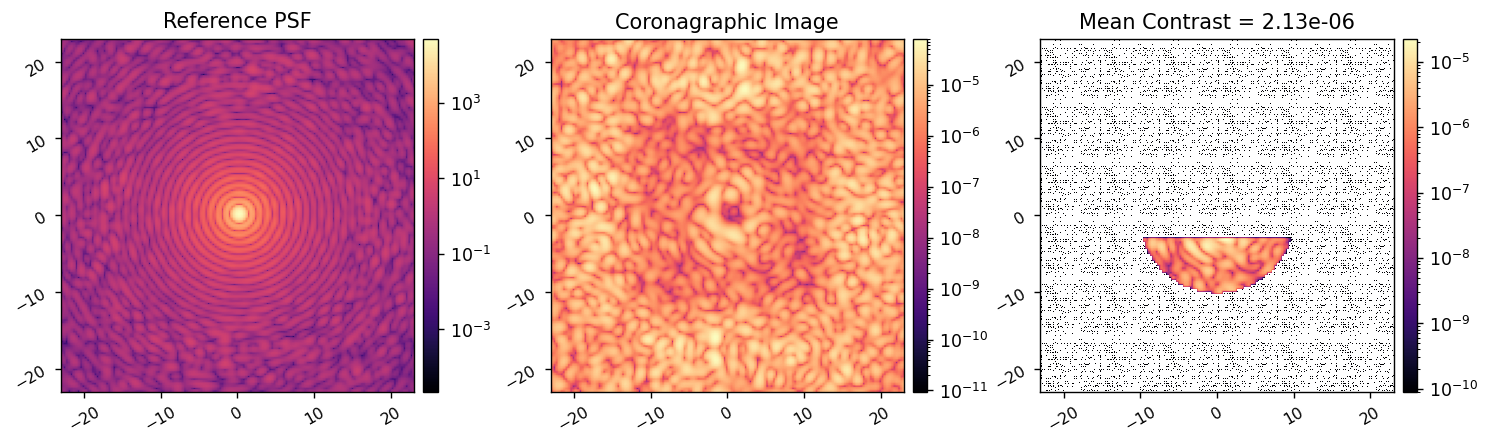

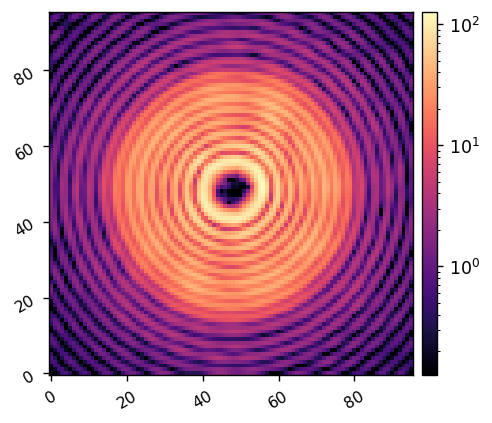

In [15]:
reload(scoobm)
reload(utils)

M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
)
M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

# M.dm_ref = wfe_data['DM_FLAT']
# M.reset_dm()

iwa = 3
owa = 10
control_mask = utils.create_annular_focal_plane_mask(
    M.ncamsci, 
    M.camsci_pxscl_lamD, 
    iwa, 
    owa,  
    edge=iwa,
    rotation=90,
)

M.use_vortex = 0
ref_psf = M.snap_camsci()
M.Imax_ref = xp.max(ref_psf)

M.use_vortex = 1
camsci_im0 = M.snap_camsci()
mean_contrast = xp.mean(camsci_im0[control_mask])

imshow3(
    ref_psf, camsci_im0, camsci_im0*control_mask,
    'Reference PSF', 'Coronagraphic Image', f'Mean Contrast = {mean_contrast:.2e}', 
    pxscl=M.camsci_pxscl_lamDc,
    lognorm=1, 
)

M.llowfsc_defocus = 3*u.mm
camlo_im0 = M.snap_camlo()
imshow1(camlo_im0, lognorm=1, vmin=xp.max(camlo_im0)/1e3)

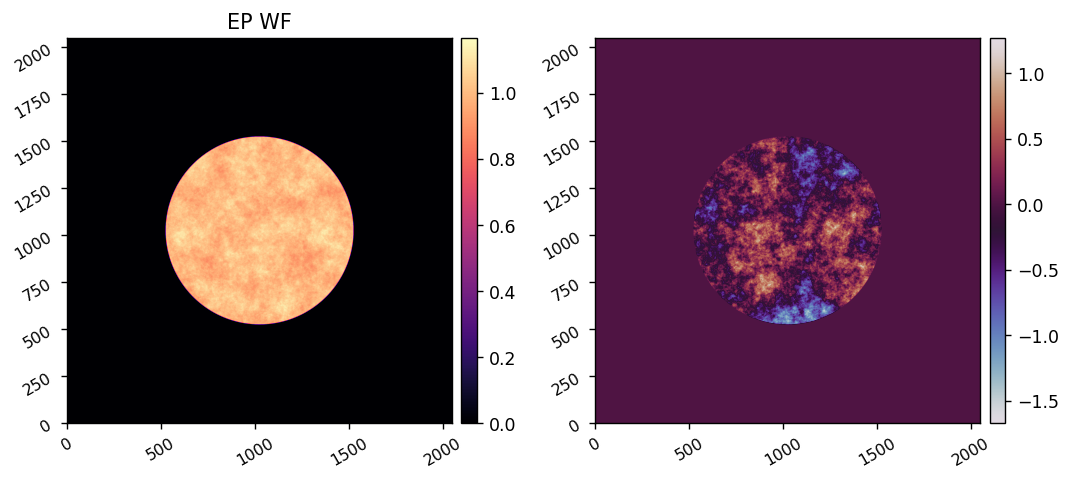

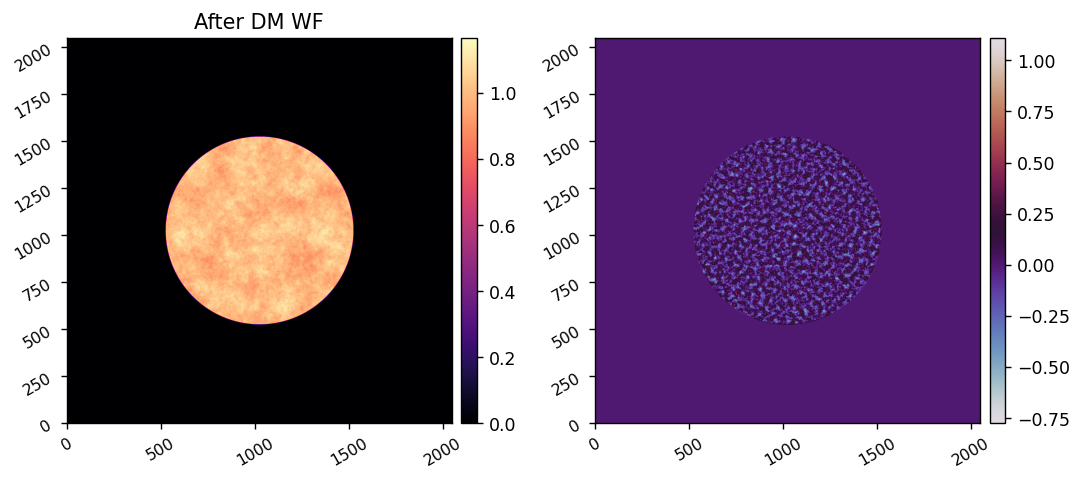

(2048, 2048)


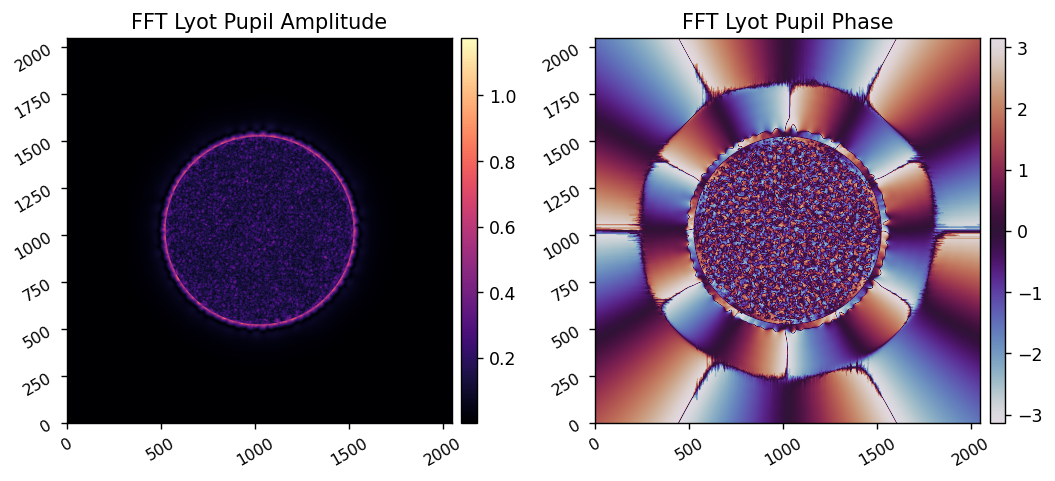

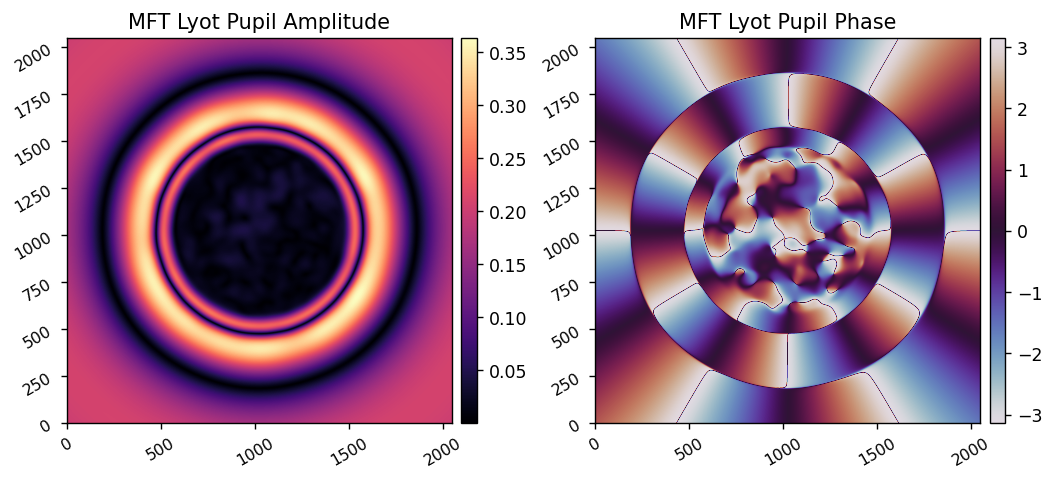

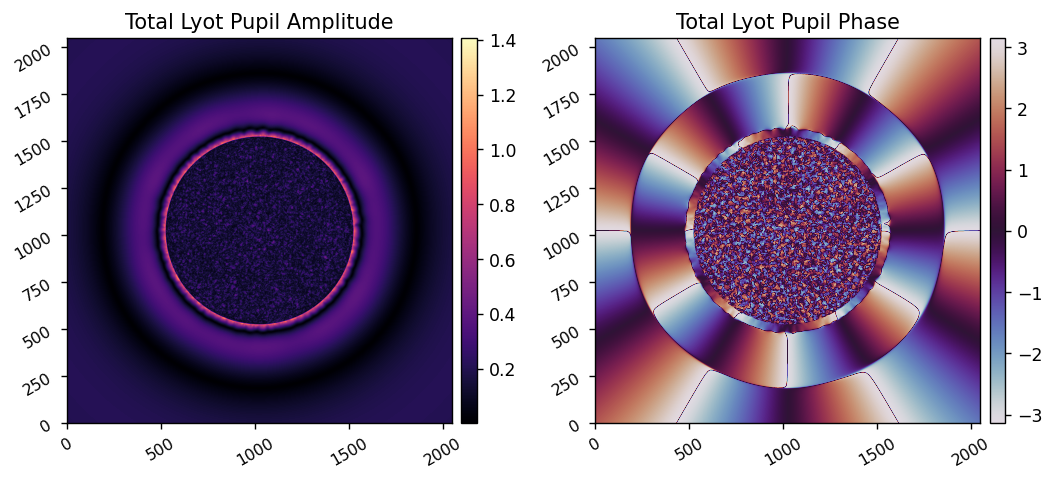

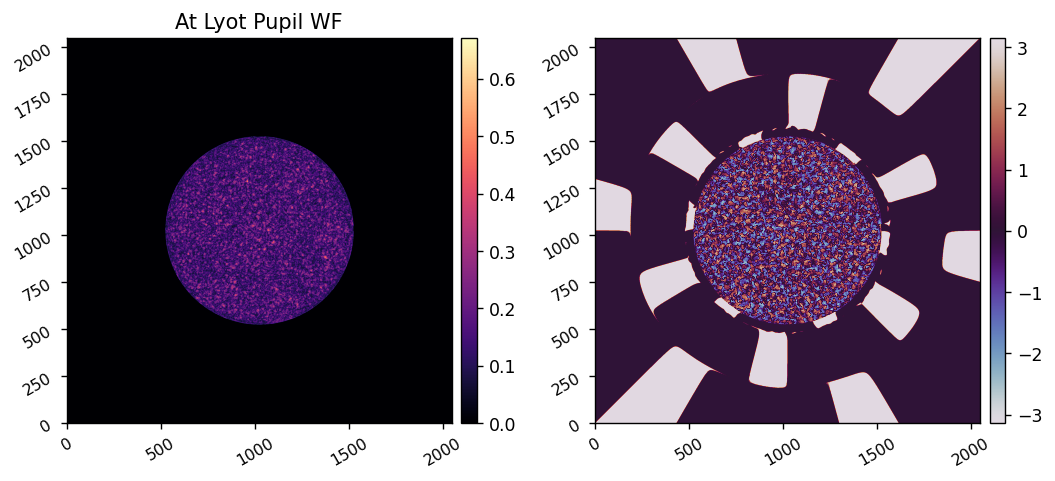

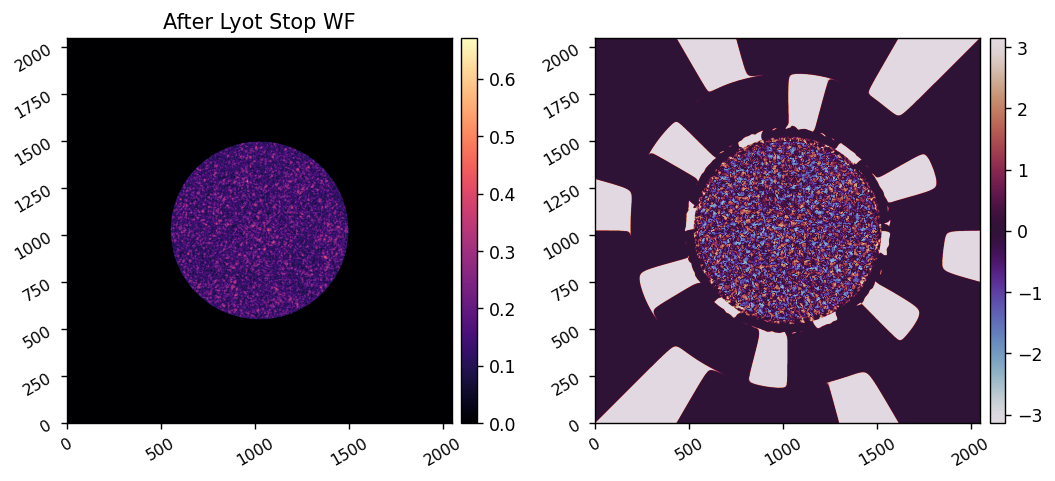

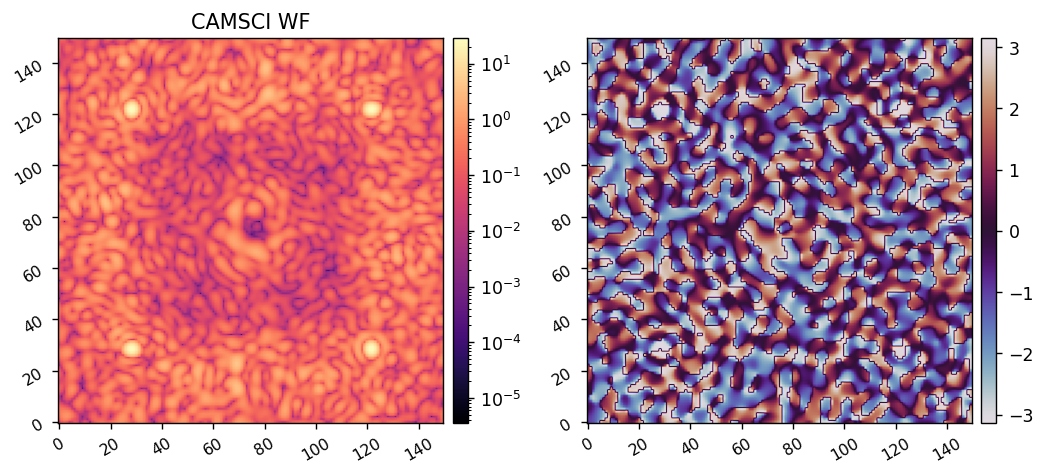

In [13]:
reload(utils)
M.plot_oversample = 2.048
M.reset_dm()

waffle_command = 10e-9 * utils.make_fourier_command(x_cpa=17, y_cpa=17, Nact=M.Nact)
M.add_dm(waffle_command)

E_EP, DM_PHASOR, E_DM, E_LP, E_LS, E_CAMSCI = M.calc_wfs_camsci(plot=1)

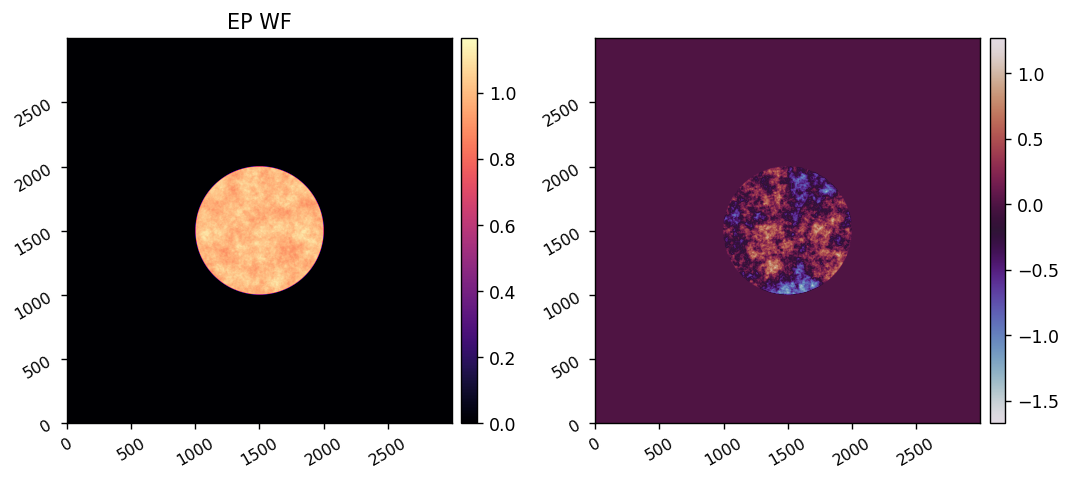

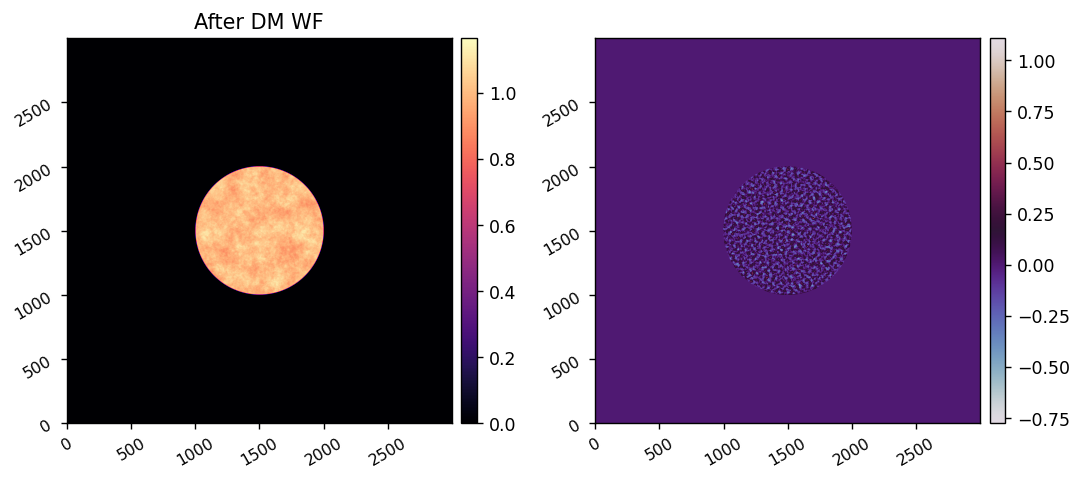

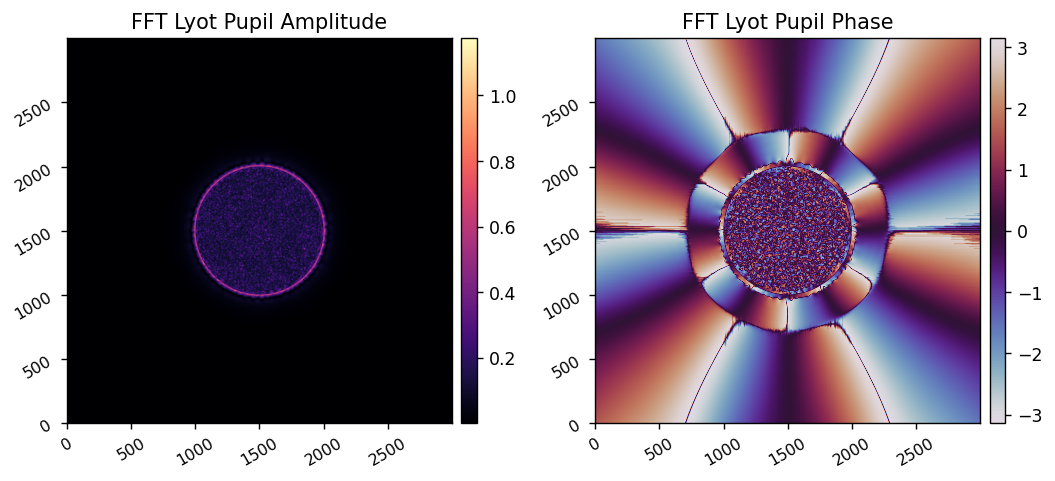

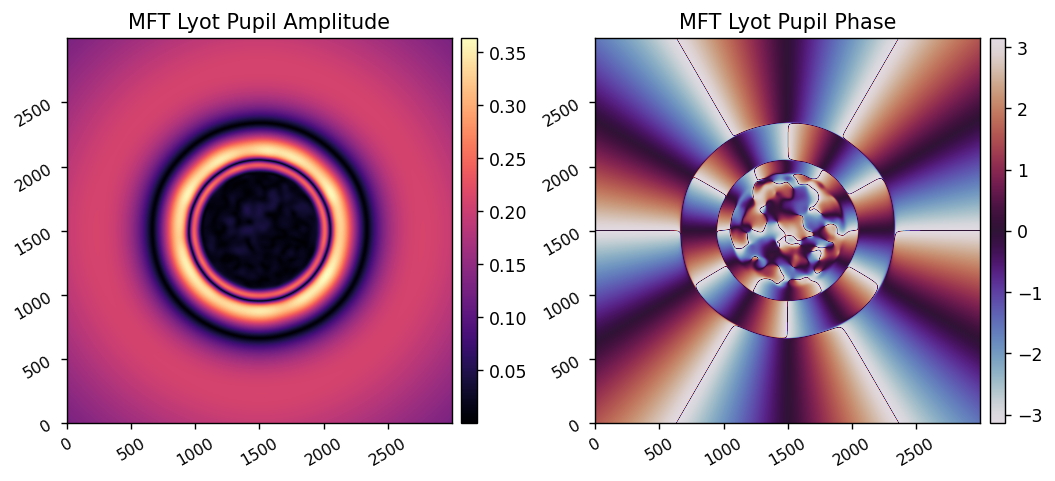

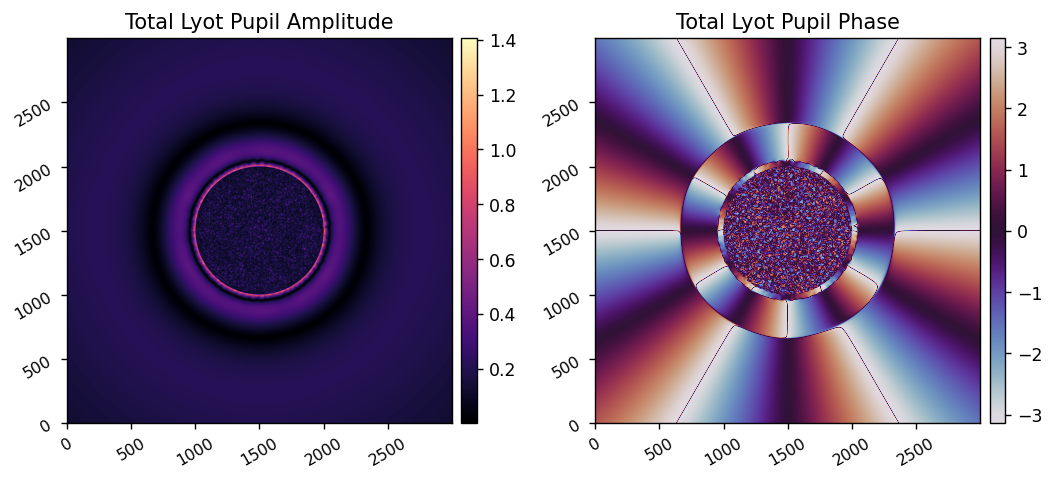

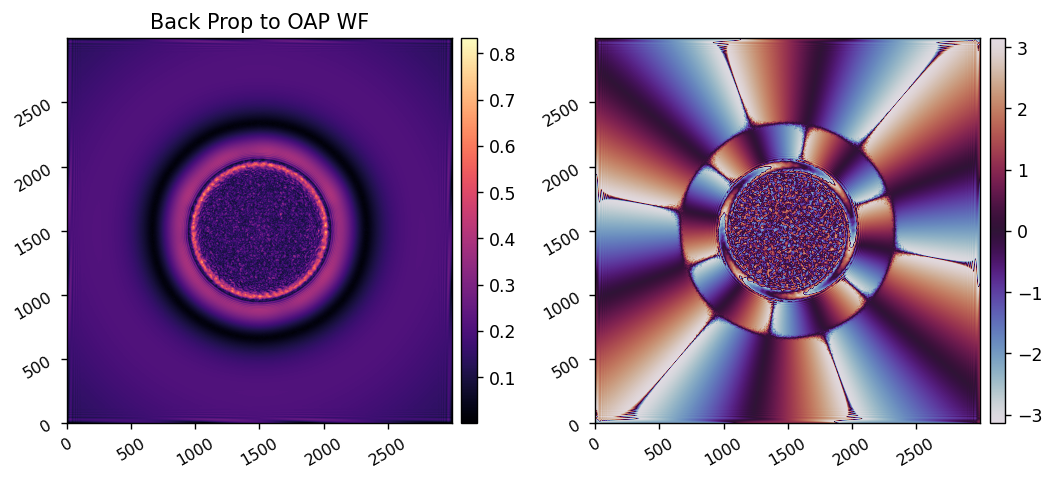

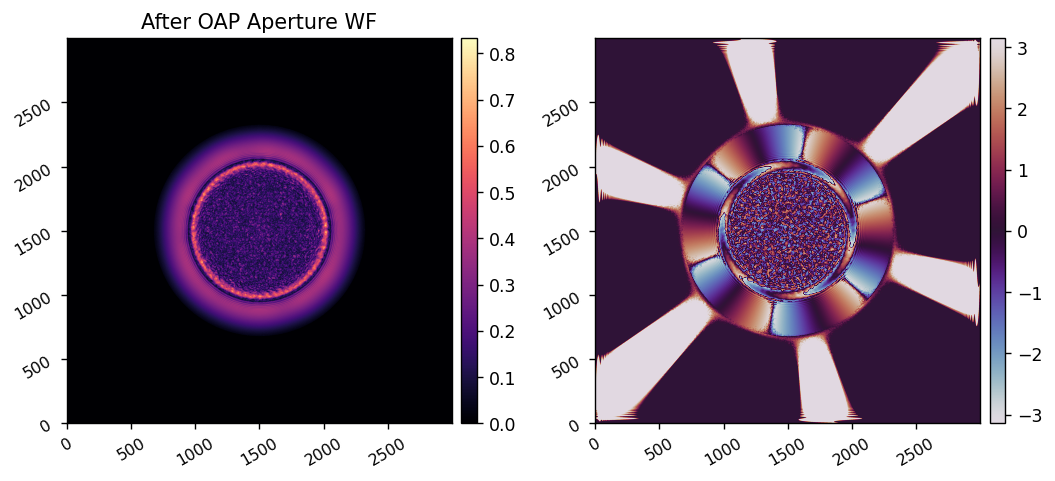

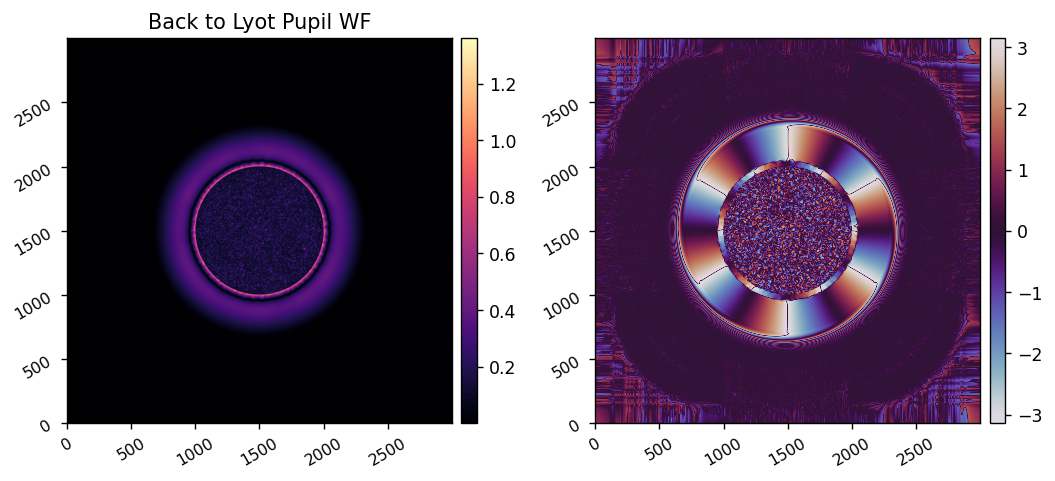

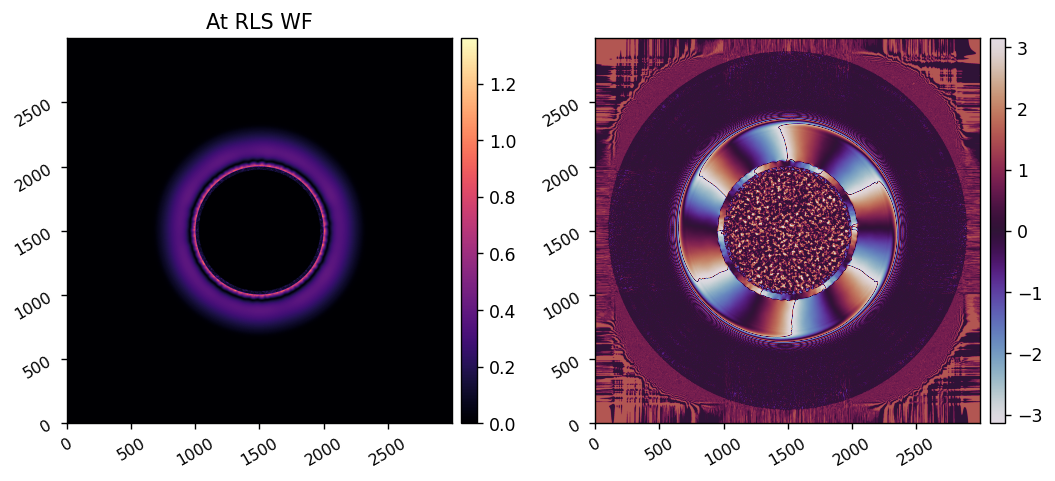

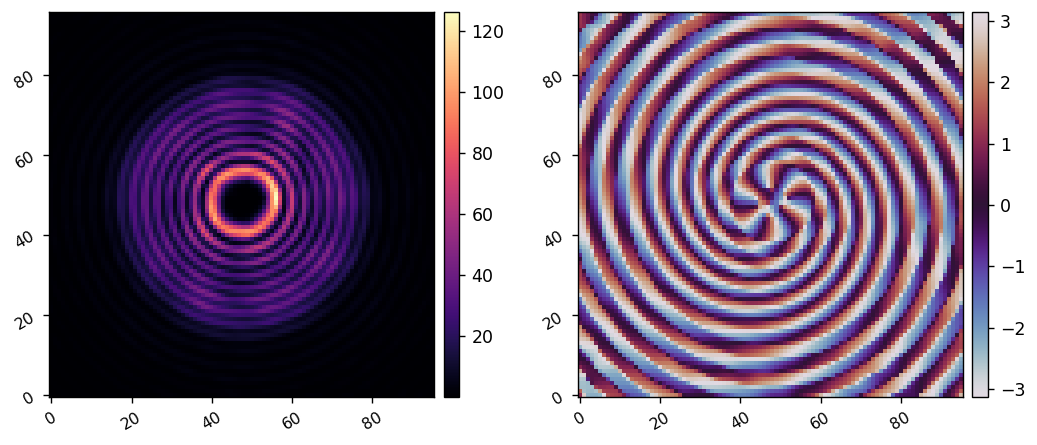

In [19]:
M.plot_oversample = 3
M.reset_dm()

# M.d_oap_ls = 150*u.mm

waffle_command = 10e-9 * utils.make_fourier_command(x_cpa=17, y_cpa=17, Nact=M.Nact)
M.add_dm(waffle_command)

E_EP, DM_PHASOR, E_DM, E_LP, E_RLS, E_CAMLO = M.calc_wfs_camlo(plot=1)



Oversampling > 2x suggested for reliable results in Fresnel propagation.


(2048, 2048)
(2048, 2048)
Expected Flux for a 2.4m aperture: 4.524e+09 ph / s
Flux in the model aperture: 4.521e+09

Expected Flux through the Lyot Stop: 4.038e+09
Measured flux of the CAMSCI PSF: 4.006e+09

Measured flux at Reflective Lyot Stop: 6.288e+08
Measured flux ratio at Reflective Lyot Stop: 0.139
Measured flux of the CAMLO Image: 6.162e+08


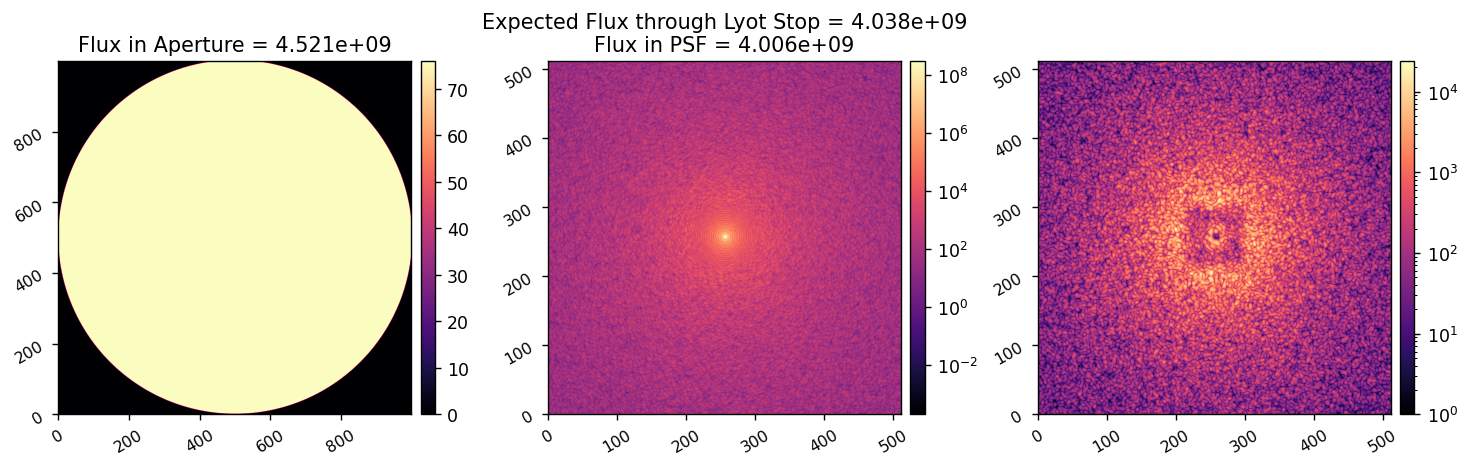

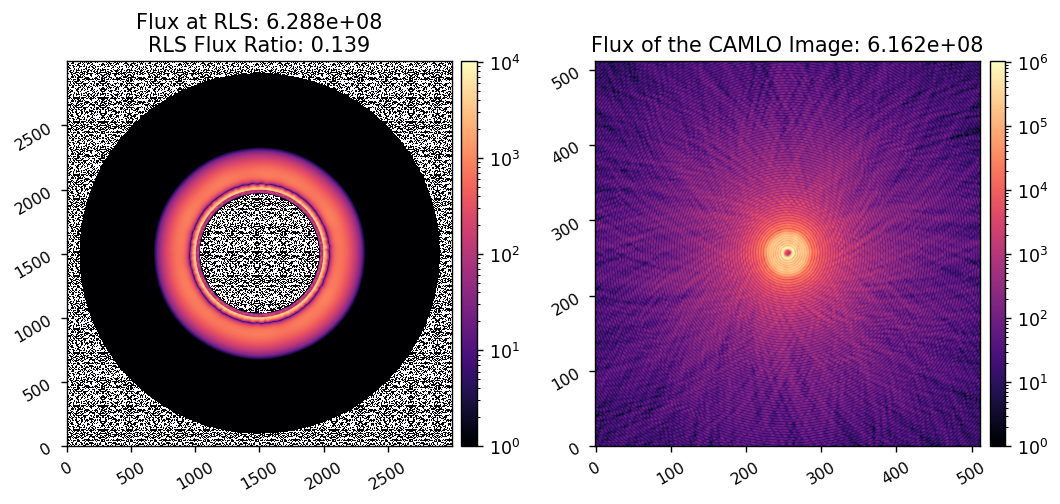

In [20]:
reload(scoobm)
pupil_flux = 1e9 * u.ph/u.s/u.m**2
M = scoobm.single(
    dm_ref=wfe_data['DM_FLAT'],
    entrance_flux=pupil_flux,
)
M.ncamsci = 512
M.ncamlo = 512

M.PREFPM_AMP = wfe_data['PREFPM_AMP']
M.PREFPM_OPD = wfe_data['PREFPM_OPD']

M.POSTFPM_AMP = wfe_data['POSTFPM_AMP']
M.POSTFPM_OPD = wfe_data['POSTFPM_OPD']

M.RLS_AMP = wfe_data['RLS_AMP']
M.RLS_OPD = wfe_data['RLS_OPD']

camsci_psf = M.snap_camsci()

M.setattr('use_vortex', True)
# coro_im = M.snap_camsci()
# camlo_im = M.snap_camlo()

E_EP, DM_PHASOR, E_DM, E_LP, E_LS, E_CAMSCI = M.calc_wfs_camsci()
camsci_im = xp.abs(E_CAMSCI)**2

E_EP, DM_PHASOR, E_DM, E_LP, E_RLS, E_CAMLO = M.calc_wfs_camlo()
rls_flux = xp.abs(E_RLS)**2
camlo_im = xp.abs(E_CAMLO)**2

expected_flux = pupil_flux * np.pi * M.total_pupil_diam**2/4
flux_in_aperture = xp.sum(xp.square( M.APERTURE ))
flux_through_ls = M.lyot_ratio**2 * flux_in_aperture
flux_in_psf = xp.sum(camsci_psf)
flux_in_camlo = xp.sum(camlo_im)

print(f'Expected Flux for a 2.4m aperture: {expected_flux:.3e}')
print(f'Flux in the model aperture: {flux_in_aperture:.3e}')
print()

print(f'Expected Flux through the Lyot Stop: {flux_through_ls:.3e}')
print(f'Measured flux of the CAMSCI PSF: {flux_in_psf:.3e}')
print()

flux_at_rls = xp.sum(rls_flux)
rls_flux_ratio = flux_at_rls/flux_in_aperture
print(f'Measured flux at Reflective Lyot Stop: {flux_at_rls:.3e}')
print(f'Measured flux ratio at Reflective Lyot Stop: {rls_flux_ratio:.3f}')
print(f'Measured flux of the CAMLO Image: {flux_in_camlo:.3e}')

imshow3(
    M.APERTURE, camsci_psf, camsci_im, 
    f'Flux in Aperture = {flux_in_aperture:.3e}', 
    f'Expected Flux through Lyot Stop = {flux_through_ls:.3e}\nFlux in PSF = {flux_in_psf:.3e}', 
    lognorm2=True, lognorm3=True, vmin3=1e0,
)

imshow2(
    rls_flux, camlo_im,
    f'Flux at RLS: {flux_at_rls:.3e}\nRLS Flux Ratio: {rls_flux_ratio:.3f}',
    f'Flux of the CAMLO Image: {flux_in_camlo:.3e}',
    lognorm1=True, vmin1=1e0,
    lognorm2=True, vmin2=1e0,
    npix1=3000,
)